# Linear Regression with scikit-learn

This notebook shows a simple, working example using `sklearn.linear_model.LinearRegression`.


In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.set_printoptions(precision=3, suppress=True)


## 1) Create a synthetic dataset
We generate a dataset with a known linear relationship, plus small noise.


In [2]:
# Make a regression dataset with 2 features and controlled noise
X, y = make_regression(
    n_samples=200,
    n_features=2,
    noise=8.0,
    random_state=7,
)

# Split into train and test sets for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)


## 2) Fit a linear regression model
We train a model on the training data and inspect the learned weights.


In [3]:
# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Learned parameters
print('Intercept:', model.intercept_)
print('Weights:', model.coef_)


Intercept: -0.7300033811668278
Weights: [46.526 93.336]


## 3) Evaluate on the test set
We compute MSE and R^2 to see how well the model generalizes.


In [4]:
# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Test MSE:', mse)
print('Test R^2:', r2)


Test MSE: 71.06541058222714
Test R^2: 0.9901128835097991


## 4) Make a single prediction
We predict the target value for a new data point.


In [5]:
# Example new data point with 2 features
x_new = np.array([[0.5, -1.2]])

# Predict the target value
y_new = model.predict(x_new)
print('Prediction for x_new:', y_new)


Prediction for x_new: [-89.47]


## 5) Different scenarios (including a weird one)
Linear regression assumes a straight-line relationship.
We will compare three scenarios: clean linear, noisy linear, and a weird non-linear pattern.


In [6]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Scenario A: clean linear data
x_a = np.linspace(0, 10, 40)
y_a = 3.0 * x_a + 2.0

# Scenario B: linear with noise
x_b = np.linspace(0, 10, 40)
y_b = 3.0 * x_b + 2.0 + rng.normal(0, 5, size=len(x_b))

# Scenario C: weird non-linear pattern (sinusoidal)
x_c = np.linspace(0, 10, 80)
y_c = 10 * np.sin(x_c) + rng.normal(0, 1.0, size=len(x_c))


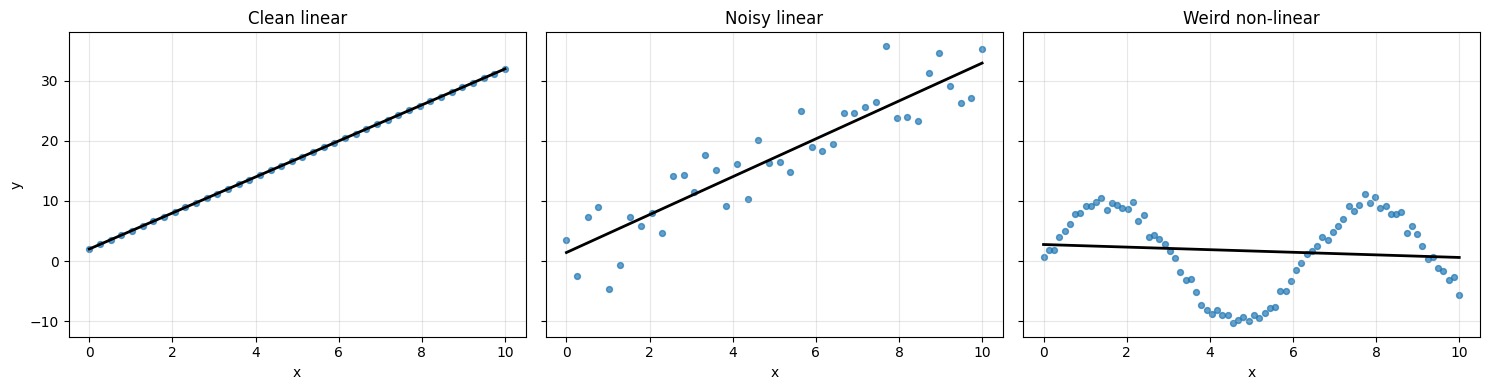

In [7]:
# Fit a linear model to each scenario and plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

def fit_and_plot(ax, x, y, title):
    # Reshape for sklearn (n_samples, n_features)
    X = x.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    y_hat = model.predict(X)
    ax.scatter(x, y, s=18, alpha=0.7)
    ax.plot(x, y_hat, color='black', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

fit_and_plot(axes[0], x_a, y_a, 'Clean linear')
fit_and_plot(axes[1], x_b, y_b, 'Noisy linear')
fit_and_plot(axes[2], x_c, y_c, 'Weird non-linear')

axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()


**What to notice:**
- Clean linear: the line fits perfectly.
- Noisy linear: the line captures the trend but not all points.
- Weird non-linear: a straight line is a poor fit because the pattern bends.


## End-to-end learning links (linear regression)
Spend time on these to see real workflows, datasets, and reporting.

- scikit-learn LinearRegression docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- scikit-learn tutorial (linear models): https://scikit-learn.org/stable/modules/linear_model.html
- statsmodels OLS docs: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- ISLR free book (Chapter 3: linear regression): https://www.statlearning.com/
- Kaggle course: Intro to Machine Learning (linear regression + evaluation): https://www.kaggle.com/learn/intro-to-machine-learning
- Kaggle dataset (House Prices): https://www.kaggle.com/c/house-prices-advanced-regression-techniques
- UCI Housing dataset: https://archive.ics.uci.edu/ml/datasets/Housing
- Python Data Science Handbook (linear regression with sklearn): https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html


## Lasso vs Ridge (simple intuition)

Both add a penalty to linear regression to reduce overfitting.

**Simple example:**
Imagine 10 features, but only 2 really matter.
- **Lasso** can push some weights to exactly 0, so it may keep only the important 2.
- **Ridge** keeps all features but shrinks all weights so none dominate.

**When to use what:**
- Use **Lasso** when you want feature selection and a simpler model.
- Use **Ridge** when many features matter a little and you do not want to drop them.
- If unsure, try both (or Elastic Net) and compare validation results.


## Lasso vs Ridge (working example)
We build data with many features, but only a few actually matter.
Lasso should zero out unhelpful features, Ridge should shrink them.


In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)
n_samples = 200
n_features = 10

# True weights: only the first 2 features matter
true_w = np.array([3.0, -2.0] + [0.0] * (n_features - 2))

X = rng.normal(0, 1, size=(n_samples, n_features))
y = X @ true_w + rng.normal(0, 0.5, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


In [ ]:
# Fit Lasso and Ridge
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Compare coefficients
print('True weights:', true_w)
print('Lasso weights:', np.round(lasso.coef_, 3))
print('Ridge weights:', np.round(ridge.coef_, 3))


In [ ]:
# Compare test performance
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print('Lasso test MSE:', mse_lasso)
print('Ridge test MSE:', mse_ridge)
